<a href="https://colab.research.google.com/github/Joeaviator/K-NEIGHHBOR/blob/main/K_NEIGHBHOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler#feature scalling
from sklearn.neighbors import KNeighborsClassifier


In [3]:
from google.colab import files
file=files.upload()

Saving sample_data.csv to sample_data.csv


#Data Exploration
* To understand what the data is about

In [4]:
df=pd.read_csv("sample_data.csv")
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1.568522,-0.443435,1.619808,-0.958255,-1.128481,0.138336,0.980493,-0.932794,1.008313,-1.069627,0
1,-0.112376,-1.056574,1.741918,-1.504220,0.640009,1.081552,-1.182663,-0.461864,0.258321,-1.041546,1
2,0.660647,-0.436981,0.775793,0.213394,-0.053171,2.030872,-1.240707,1.149298,2.184784,0.342811,1
3,0.011533,0.191324,-1.433473,-0.100053,-1.507223,-1.753632,-1.183561,-0.888557,0.162310,-0.002793,0
4,-0.099059,0.820815,-0.904346,1.609015,-0.282065,-0.365099,-1.095644,0.391419,-1.365603,0.787762,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   XVPM          500 non-null    float64
 1   GWYH          500 non-null    float64
 2   TRAT          500 non-null    float64
 3   TLLZ          500 non-null    float64
 4   IGGA          500 non-null    float64
 5   HYKR          500 non-null    float64
 6   EDFS          500 non-null    float64
 7   GUUB          500 non-null    float64
 8   MGJM          500 non-null    float64
 9   JHZC          500 non-null    float64
 10  TARGET CLASS  500 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 43.1 KB


In [6]:
#column names-feature extraction
df.columns

Index(['XVPM', 'GWYH', 'TRAT', 'TLLZ', 'IGGA', 'HYKR', 'EDFS', 'GUUB', 'MGJM',
       'JHZC', 'TARGET CLASS'],
      dtype='object')

In [7]:
y=df.pop('TARGET CLASS')
x=df
#x=df.drop(columns=['TARGET CLASS'],axis=1)
#y=df['TARGET CLASS']


In [8]:
x.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC
0,1.568522,-0.443435,1.619808,-0.958255,-1.128481,0.138336,0.980493,-0.932794,1.008313,-1.069627
1,-0.112376,-1.056574,1.741918,-1.504220,0.640009,1.081552,-1.182663,-0.461864,0.258321,-1.041546
2,0.660647,-0.436981,0.775793,0.213394,-0.053171,2.030872,-1.240707,1.149298,2.184784,0.342811
3,0.011533,0.191324,-1.433473,-0.100053,-1.507223,-1.753632,-1.183561,-0.888557,0.162310,-0.002793
4,-0.099059,0.820815,-0.904346,1.609015,-0.282065,-0.365099,-1.095644,0.391419,-1.365603,0.787762


In [9]:
#split the dataintotesting and training
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [10]:
#feature scaling-all points are on the scale
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [14]:
x_train[10]

array([-0.98164675,  0.01139356, -1.32720185,  0.33143324,  1.6478495 ,
       -0.40915159, -1.3080312 ,  0.94538631, -1.02397151,  0.27931189])

In [17]:
#load the algorithm
error_rates=[] #stor the models performance across differncent ks
for k in range(1,41):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train,y_train)
  #Make predictions
  preds=knn.predict(x_test)
  #Evalate the algorithm
  errors=np.mean(preds!=y_test)
  #add the errorsinto the dictionary
  error_rates.append(errors)

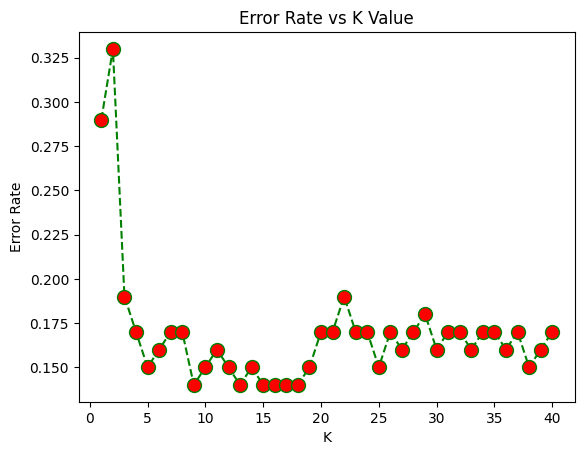

In [20]:
#Visualize the model's performance
plt.plot(range(1,41),error_rates,color='green',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [21]:
#determine the best K
best_k=error_rates.index(min(error_rates))+1
print(f"Best K value:{best_k}")

Best K value:9
